In [94]:
from pathlib import Path
import pandas as pd
import numpy as np
import sys
ROOT = Path.cwd().parent.parent
sys.path.append(str(ROOT))
import matplotlib.pyplot as plt
import forestplot as fp

In [95]:
data_path = Path(ROOT / 'data' / 'logistic_coefficients' / 'logistic_coef_results.csv')
df = pd.read_csv(data_path)

In [96]:
cols = [c for c in df.columns if c != 'odds_ratios']
print(cols)
pivoted = df.pivot(
    index='feature_names',
    columns='year',
    values=['odds_ratios', 'pvalues', 'confidence_lower', 'confidence_upper', 'std_error']
)
pivoted.head()

['feature_names', 'pvalues', 'confidence_lower', 'confidence_upper', 'std_error', 'year']


odds_ratios                                                    \
year              2016/17   2017/18   2018/19   2019/20   2020/21   2021/22   
feature_names                                                                 
Age9_3.0         1.163621  1.301227  1.435886  1.264762  1.095283  1.335702   
Age9_4.0         1.210899  1.223039  1.336121  1.177578  1.074461  1.257396   
Age9_5.0         1.212424  1.269732  1.278958  1.231481  1.214439  1.415026   
Age9_6.0         1.068632  1.026240  1.140626  1.238687  1.263395  1.195155   
Age9_7.0         0.775701  0.731010  0.850167  0.960534  1.013885  0.867574   

                          pvalues                      ... confidence_upper  \
year            2022/23   2016/17   2017/18   2018/19  ...          2020/21   
feature_names                                          ...                    
Age9_3.0       1.147670  0.090496  0.009053  0.000199  ...         1.312997   
Age9_4.0       1.131953  0.033990  0.048842  0.003350  ...         1.294396   
Age9_5.0       1.099067  0.033640  0.022080  0.014933  ...         1.467559   
Age9_6.0       0.971106  0.474474  0.814087  0.213954  ...         1.541272   
Age9_7.0       0.788968  0.004093  0.017014  0.205060  ...         1.294620   

                                  std_error                                \
year            2021/22   2022/23   2016/17   2017/18   2018/19   2019/20   
feature_names                                                               
Age9_3.0       1.616196  1.389811  0.089519  0.100882  0.097241  0.105831   
Age9_4.0       1.525757  1.371530  0.090258  0.102204  0.098776  0.109156   
Age9_5.0       1.724779  1.333809  0.090673  0.104328  0.101087  0.111697   
Age9_6.0       1.467633  1.186302  0.092809  0.110147  0.105874  0.118493   
Age9_7.0       1.114802  1.003048  0.088469  0.131297  0.128089  0.148436   

                                             
year            2020/21   2021/22   2022/23  
feature_names                                
Age9_3.0       0.092501  0.097256  0.097672  
Age9_4.0       0.095015  0.098700  0.097952  
Age9_5.0       0.096593  0.100997  0.098766  
Age9_6.0       0.101433  0.104785  0.102125  
Age9_7.0       0.124710  0.127926  0.122489  

[5 rows x 35 columns]

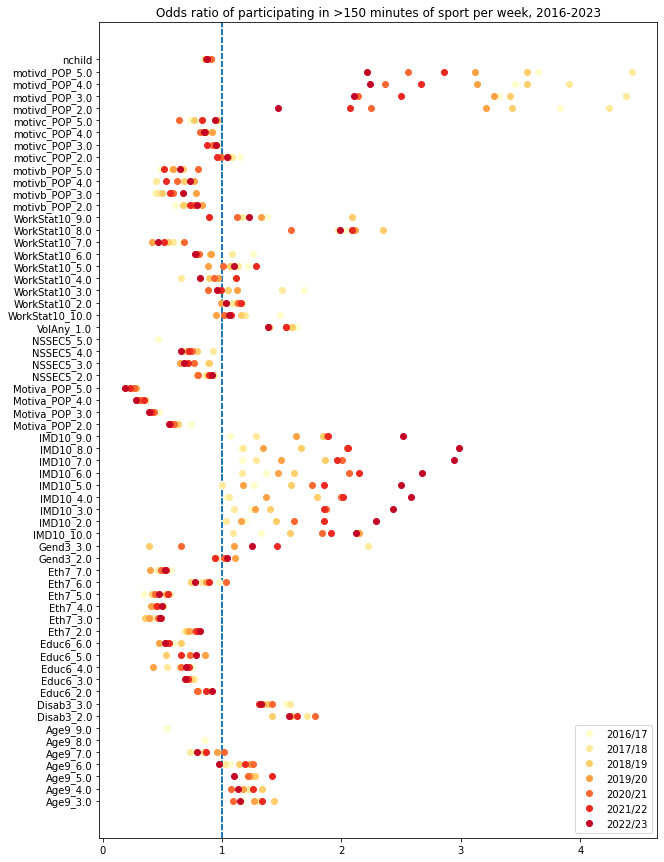

In [97]:
fig, ax = plt.subplots(figsize=(10,15))
ax.set_prop_cycle(color = plt.cm.YlOrRd(np.linspace(0,1,8)))
for idx, year in enumerate(sorted(df['year'].unique())):
    ax.errorbar(x=pivoted['odds_ratios'][year].values, y =pivoted.index, marker='o', linestyle='None', label=year)
    ax.legend()
    ax.set_title('Odds ratio of participating in >150 minutes of sport per week, 2016-2023')
    ax.axvline(x=1, linestyle='--')

